# German Credit Risk Modeling 

## Project objective
Build a complete credit-risk classification pipeline to predict whether a customer is **good** or **bad** credit risk.



In [4]:
# 1. Import libraries
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.utils.class_weight import compute_class_weight

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

print("Libraries loaded.")


Libraries loaded.


In [5]:
# 2. Load dataset
DATA_PATH = "german_credit_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/german_credit_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1000, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## 3. Understand the dataset

The target variable is `Risk`.

- `good` = good credit risk
- `bad` = bad credit risk

The `Unnamed: 0` column is only an index-like identifier and is removed before modeling because it does not represent customer behavior.


In [6]:
# 3. Basic inspection
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nSummary statistics:")
display(df.describe(include="all").T)


Shape: (1000, 11)

Data types:


,dtype
Unnamed: 0,int64
Age,int64
Sex,str
Job,int64
Housing,str
Saving accounts,str
Checking account,str
Credit amount,int64
Duration,int64
Purpose,str



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# 4. Duplicate check
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [8]:
# 5. Missing-value analysis
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_pct
})

display(missing_table[missing_table["Missing Count"] > 0])


,Missing Count,Missing Percentage
Checking account,394,39.4
Saving accounts,183,18.3


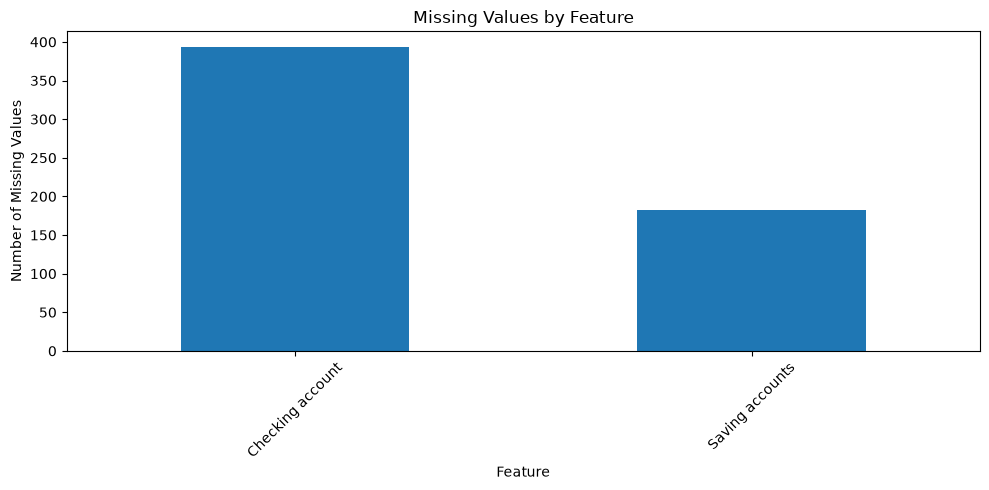

In [9]:
# 6. Missing-value visualization
plt.figure(figsize=(10,5))
missing_table[missing_table["Missing Count"] > 0]["Missing Count"].plot(kind="bar")
plt.title("Missing Values by Feature")
plt.ylabel("Number of Missing Values")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Why we should not use `dropna()`

The two important incomplete variables are:

- `Saving accounts`
- `Checking account`

Dropping rows removes customers from the modeling sample. Instead, categorical missing values are imputed with the most frequent category **inside the training pipeline**.

This preserves the dataset while ensuring that information from the test set is not used to calculate preprocessing values.


In [10]:
# 7. Show the effect of the old dropna approach
rows_before = len(df)
rows_after_dropna = len(df.dropna())

print(f"Rows before dropna: {rows_before}")
print(f"Rows after dropna:  {rows_after_dropna}")
print(f"Rows lost:          {rows_before - rows_after_dropna}")
print(f"Percentage lost:    {(rows_before - rows_after_dropna)/rows_before*100:.2f}%")


Rows before dropna: 1000
Rows after dropna:  522
Rows lost:          478
Percentage lost:    47.80%


,Count
Risk,
good,700
bad,300


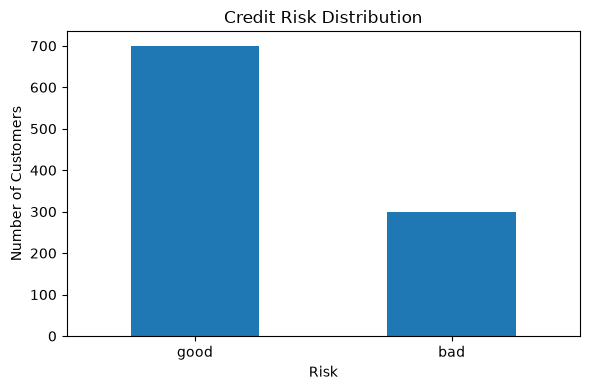

In [11]:
# 8. Target distribution before modeling
target_counts = df["Risk"].value_counts()

display(target_counts.to_frame("Count"))

plt.figure(figsize=(6,4))
target_counts.plot(kind="bar")
plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Exploratory Data Analysis

We examine the variables most relevant to credit risk: age, credit amount, loan duration, housing, checking account, savings account, purpose and job.


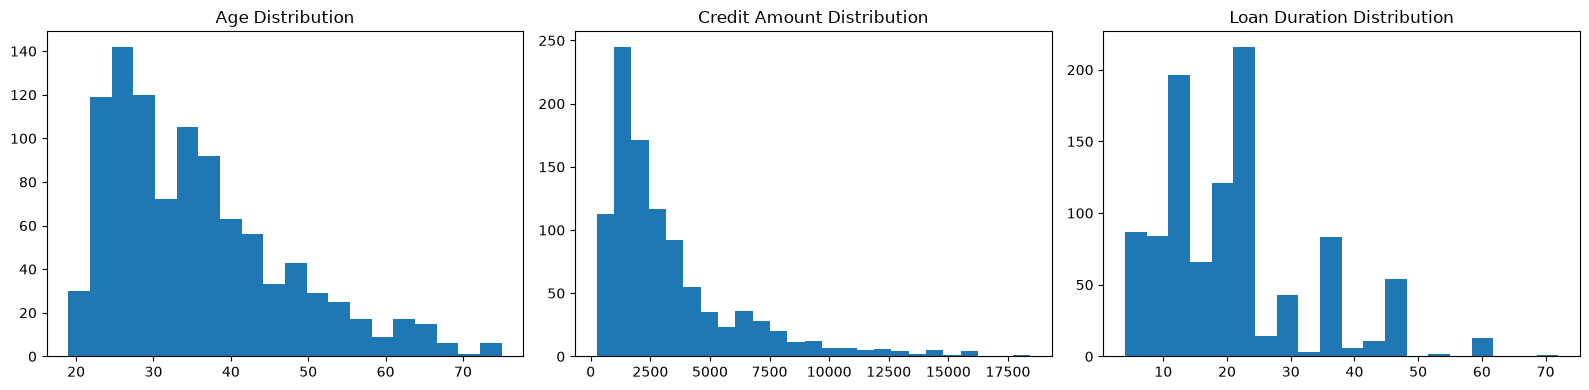

In [12]:
# 9. Numerical distributions
fig, axes = plt.subplots(1, 3, figsize=(16,4))

axes[0].hist(df["Age"].dropna(), bins=20)
axes[0].set_title("Age Distribution")

axes[1].hist(df["Credit amount"].dropna(), bins=25)
axes[1].set_title("Credit Amount Distribution")

axes[2].hist(df["Duration"].dropna(), bins=20)
axes[2].set_title("Loan Duration Distribution")

plt.tight_layout()
plt.show()


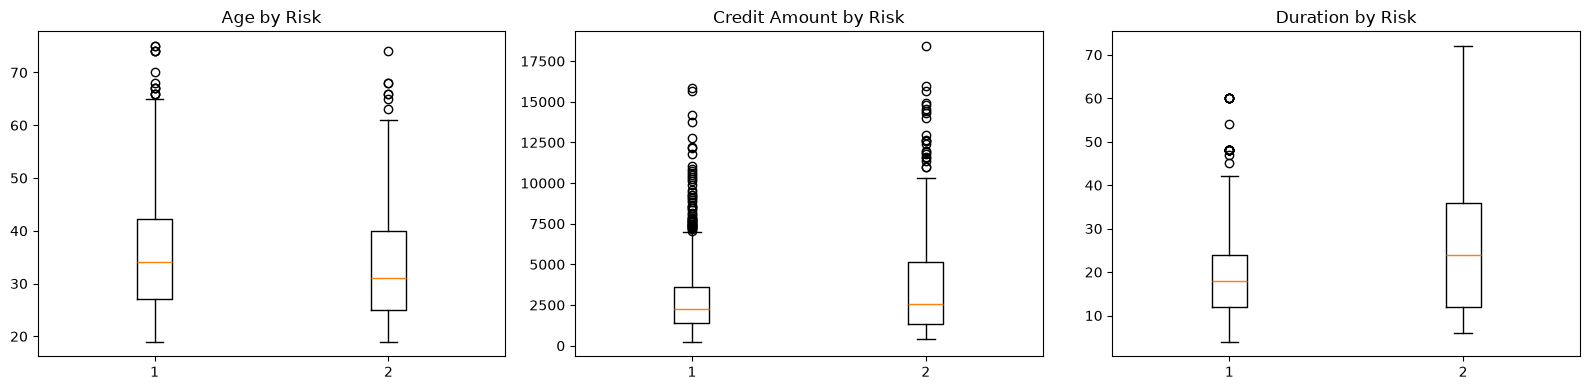

In [13]:
# 10. Risk vs numerical variables
fig, axes = plt.subplots(1, 3, figsize=(16,4))

axes[0].boxplot([df.loc[df["Risk"]==r,"Age"].dropna() for r in ["good","bad"]], label=["Good","Bad"])
axes[0].set_title("Age by Risk")

axes[1].boxplot([df.loc[df["Risk"]==r,"Credit amount"].dropna() for r in ["good","bad"]], label=["Good","Bad"])
axes[1].set_title("Credit Amount by Risk")

axes[2].boxplot([df.loc[df["Risk"]==r,"Duration"].dropna() for r in ["good","bad"]], label=["Good","Bad"])
axes[2].set_title("Duration by Risk")

plt.tight_layout()
plt.show()


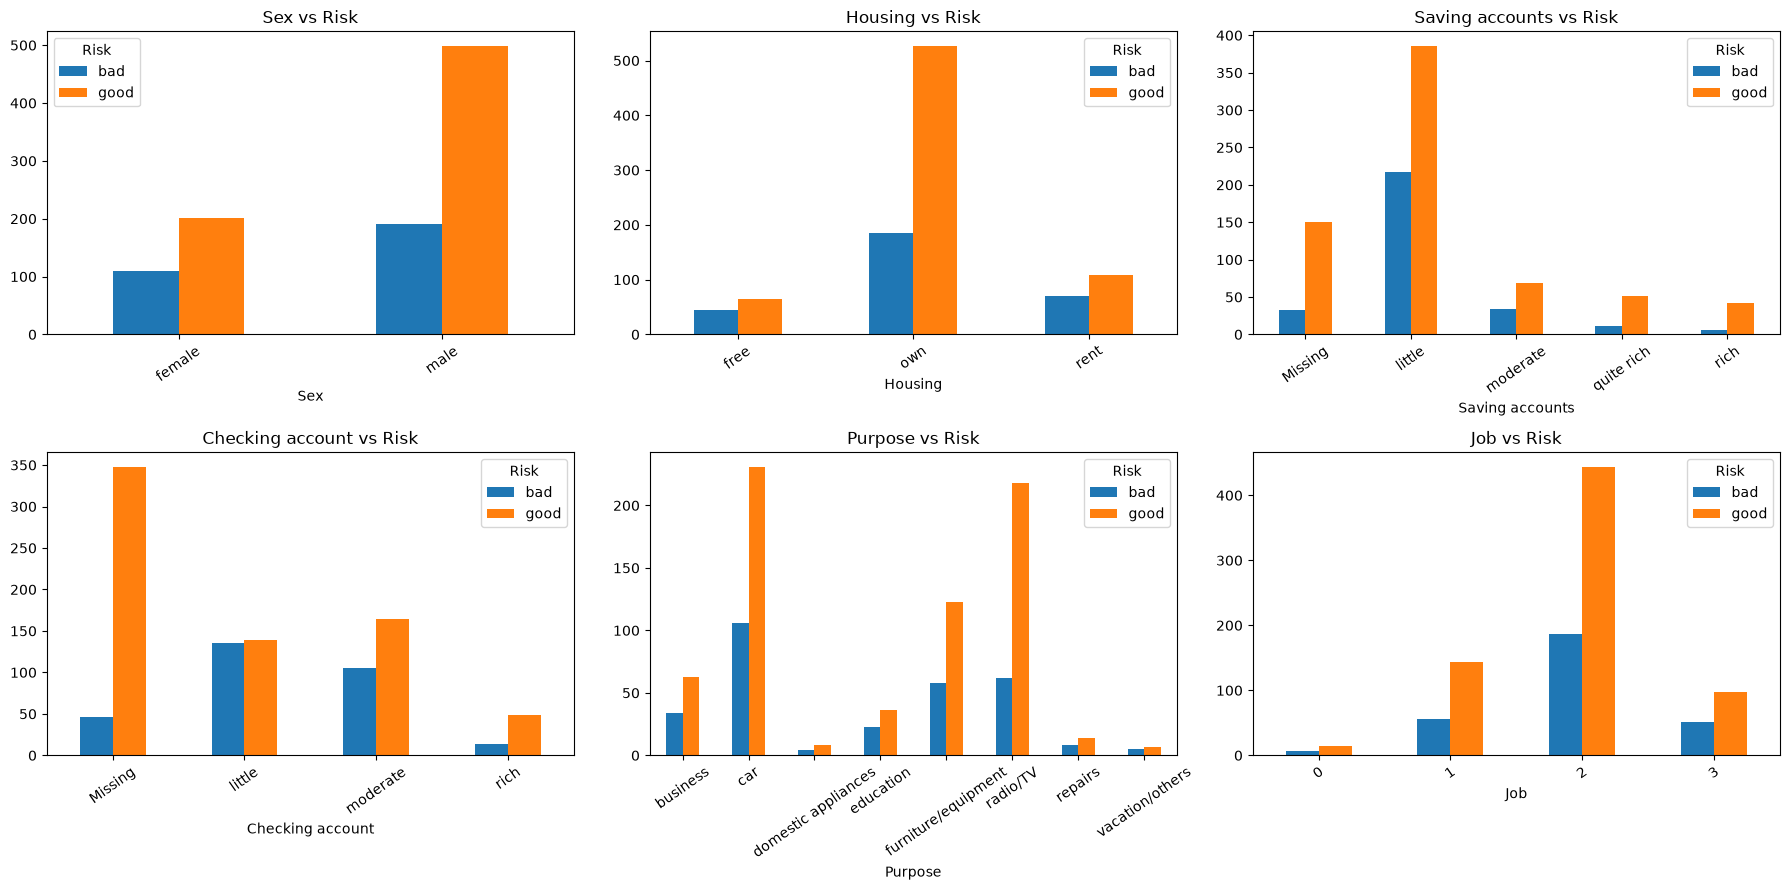

In [14]:
# 11. Categorical risk relationships
categorical_eda = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose", "Job"]

fig, axes = plt.subplots(2, 3, figsize=(18,9))
axes = axes.flatten()

for ax, col in zip(axes, categorical_eda):
    tab = pd.crosstab(df[col].fillna("Missing"), df["Risk"])
    tab.plot(kind="bar", ax=ax)
    ax.set_title(f"{col} vs Risk")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


## 5. Data preparation

### Target encoding
`good` → 0  
`bad` → 1

The positive class is therefore **bad credit**, which is useful because recall for this class is especially important in credit-risk applications.

### Missing-value strategy
- Categorical features → most-frequent imputation
- Numerical features → median imputation
- Categorical features → one-hot encoding
- Identifier column → removed


In [15]:
# 12. Separate features and target
data = df.copy()

# Remove identifier column
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

X = data.drop(columns=["Risk"])
y = data["Risk"].map({"good": 0, "bad": 1})

print("Features:", X.shape)
print("Target distribution:")
display(y.value_counts().rename(index={0:"good", 1:"bad"}))


Features: (1000, 9)
Target distribution:


Risk
good    700
bad     300
Name: count, dtype: int64

In [16]:
# 13. Identify feature types
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['Age', 'Job', 'Credit amount', 'Duration']
Categorical features: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [17]:
# 14. Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).rename(index={0:"good",1:"bad"}).round(3))


Training rows: 800
Testing rows: 200

Training target distribution:


Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

In [18]:
# 15. Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## 6. Handling class imbalance

The original complete dataset has a 70:30 good-to-bad distribution. That is an imbalance, but it does **not** mean we should delete rows.

For Logistic Regression and the tree-based models that support it, we use `class_weight="balanced"`. This gives more importance to the minority bad-credit class and helps the models pay attention to the costly class.

We evaluate **recall, precision and F1** in addition to accuracy because accuracy alone can hide poor detection of bad-risk customers.


In [19]:
# 16. Class weights
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)


Class weights: {np.int64(0): np.float64(0.7142857142857143), np.int64(1): np.float64(1.6666666666666667)}


## 7. Baseline machine-learning models

We compare:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Extra Trees
5. XGBoost (if installed)

Logistic Regression is included as a simple, interpretable linear classification baseline for the binary `good`/`bad` target.

Every model uses the same preprocessing pipeline.


In [20]:
# 17. Define models
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    )
}

if XGB_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

print("Models:", list(models.keys()))


Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees']


In [21]:
# 18. Train and evaluate baseline models
results = []
fitted_models = {}
predictions = {}
probabilities = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    fitted_models[name] = pipe
    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "Accuracy":"{:.3f}",
    "Precision":"{:.3f}",
    "Recall":"{:.3f}",
    "F1":"{:.3f}",
    "ROC-AUC":"{:.3f}"
}))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.615,0.398,0.550,0.462,0.638
1,Random Forest,0.675,0.456,0.433,0.444,0.622
2,Extra Trees,0.645,0.351,0.217,0.268,0.600
3,Decision Tree,0.595,0.333,0.350,0.341,0.525


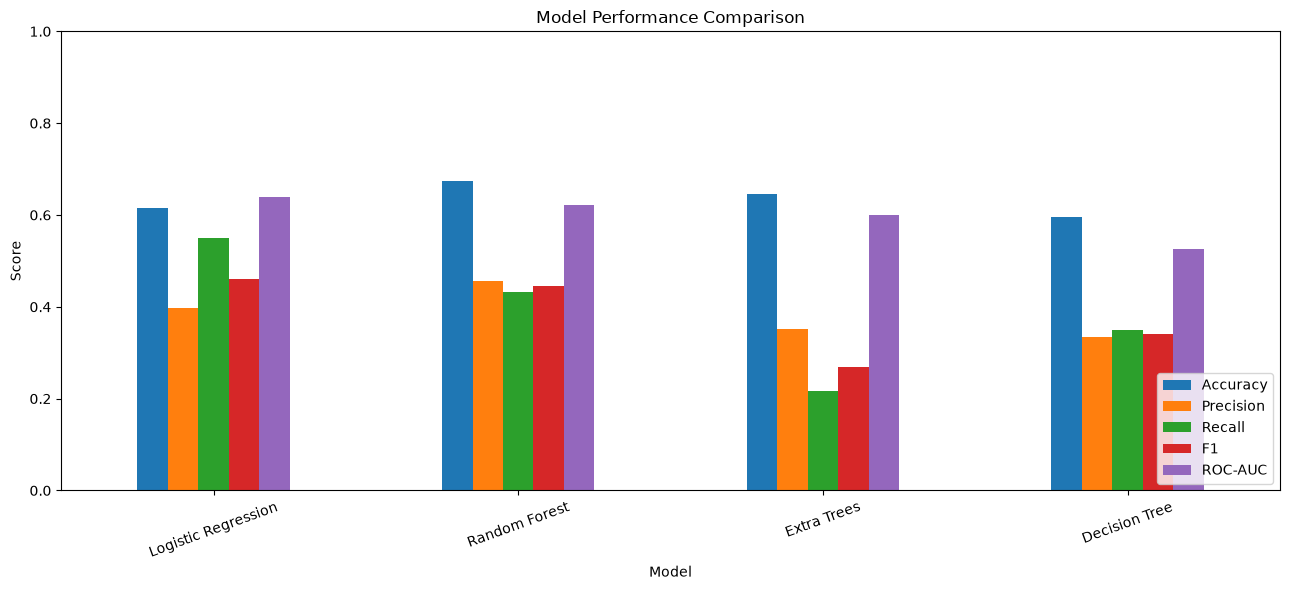

In [22]:
# 19. Model comparison
plot_df = results_df.set_index("Model")[["Accuracy","Precision","Recall","F1","ROC-AUC"]]

ax = plot_df.plot(kind="bar", figsize=(13,6))
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


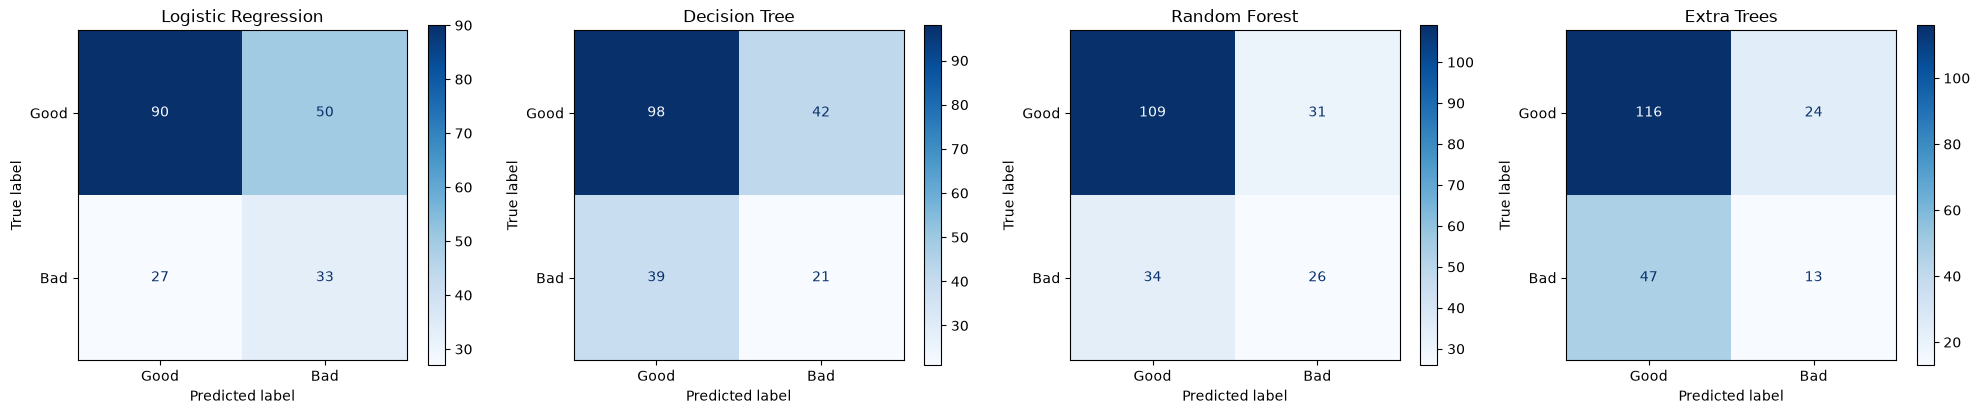

In [23]:
# 20. Confusion matrices for all models
n = len(fitted_models)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Good", "Bad"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()


<Figure size 900x600 with 0 Axes>

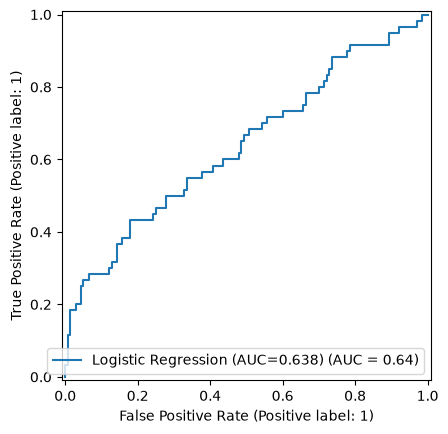

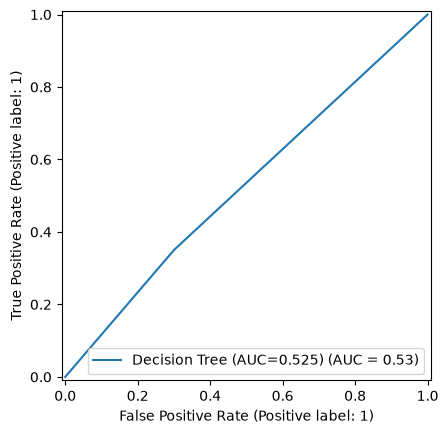

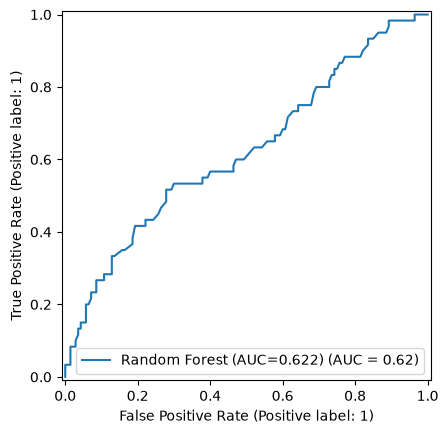

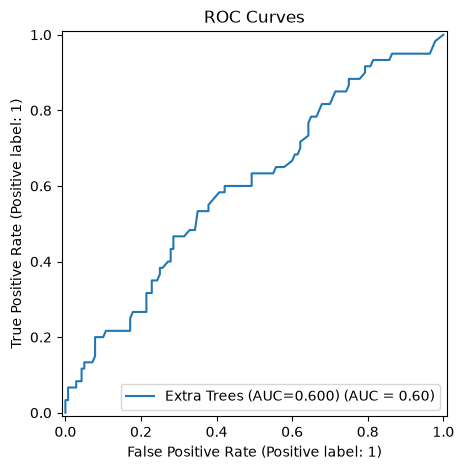

In [24]:
# 21. ROC curves
plt.figure(figsize=(9,6))

for name, y_prob in probabilities.items():
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=f"{name} (AUC={auc:.3f})"
    )

plt.title("ROC Curves")
plt.tight_layout()
plt.show()


## 8. Hyperparameter tuning

We tune the main tree-based models using stratified cross-validation.

The preprocessing remains inside the pipeline, so each CV fold learns its own imputation values. This prevents leakage.


In [25]:
# 22. Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Compact, reproducible grids: enough tuning without excessive runtime.
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__penalty": ["l2"]
    },
    "Decision Tree": {
        "model__max_depth": [5, 10],
        "model__min_samples_split": [2, 10]
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10],
        "model__min_samples_split": [2]
    },
    "Extra Trees": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10],
        "model__min_samples_split": [2]
    }
}

if XGB_AVAILABLE:
    param_grids["XGBoost"] = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05]
    }

print("Grid sizes:", {k: len(__import__('sklearn').model_selection.ParameterGrid(v)) for k,v in param_grids.items()})


Grid sizes: {'Logistic Regression': 3, 'Decision Tree': 4, 'Random Forest': 4, 'Extra Trees': 4}


In [26]:
# 23. Grid search
tuned_results = []
tuned_models = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    tuned_models[name] = best_model

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Best CV ROC-AUC": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)

display(tuned_results_df.drop(columns=["Best Parameters"]).style.format({
    "Accuracy":"{:.3f}",
    "Precision":"{:.3f}",
    "Recall":"{:.3f}",
    "F1":"{:.3f}",
    "ROC-AUC":"{:.3f}",
    "Best CV ROC-AUC":"{:.3f}"
}))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Best CV ROC-AUC
0,Random Forest,0.660,0.439,0.483,0.460,0.660,0.674
1,Logistic Regression,0.625,0.407,0.550,0.468,0.651,0.693
2,Extra Trees,0.685,0.474,0.450,0.462,0.628,0.637
3,Decision Tree,0.600,0.386,0.567,0.459,0.614,0.643


In [27]:
# 24. Print best parameters
for _, row in tuned_results_df.iterrows():
    print("\n", row["Model"])
    print(row["Best Parameters"])



 Random Forest
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 400}

 Logistic Regression
{'model__C': 0.1, 'model__penalty': 'l2'}

 Extra Trees
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 400}

 Decision Tree
{'model__max_depth': 10, 'model__min_samples_split': 10}


## 9. Final model selection

For credit risk, the final model should not be selected using accuracy alone. We consider:

- ROC-AUC: ranking/discrimination ability
- Recall for `bad`: how many risky customers are identified
- Precision: how many customers predicted as bad are actually bad
- F1: balance between precision and recall
- Accuracy: overall correctness

The notebook selects the best tuned model by **ROC-AUC** and then reports its complete classification performance.


In [28]:
# 25. Select final model by test ROC-AUC
final_row = tuned_results_df.iloc[0]
final_model_name = final_row["Model"]
final_model = tuned_models[final_model_name]

final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:, 1]

print("FINAL MODEL:", final_model_name)
print("\nClassification Report:")
print(classification_report(
    y_test, final_pred,
    target_names=["Good", "Bad"],
    digits=4,
    zero_division=0
))

print("ROC-AUC:", round(roc_auc_score(y_test, final_prob), 4))


FINAL MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

        Good     0.7687    0.7357    0.7518       140
         Bad     0.4394    0.4833    0.4603        60

    accuracy                         0.6600       200
   macro avg     0.6040    0.6095    0.6061       200
weighted avg     0.6699    0.6600    0.6644       200

ROC-AUC: 0.6604


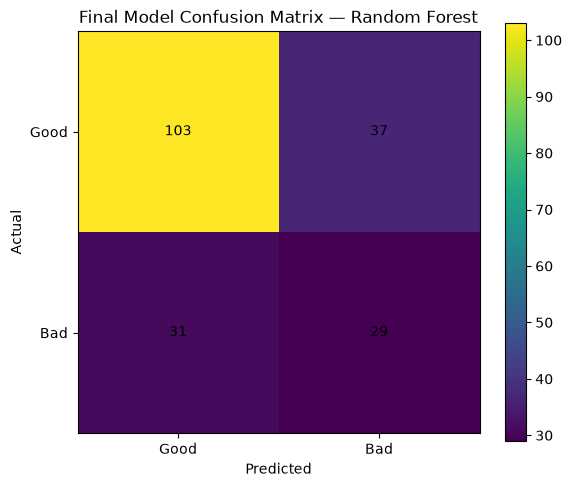

Confusion matrix:


,Predicted Good,Predicted Bad
Actual Good,103,37
Actual Bad,31,29


In [29]:
# 26. Final confusion matrix
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.xticks([0,1],["Good","Bad"])
plt.yticks([0,1],["Good","Bad"])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center",va="center")
plt.colorbar()
plt.title(f"Final Model Confusion Matrix — {final_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
display(pd.DataFrame(
    cm,
    index=["Actual Good", "Actual Bad"],
    columns=["Predicted Good", "Predicted Bad"]
))


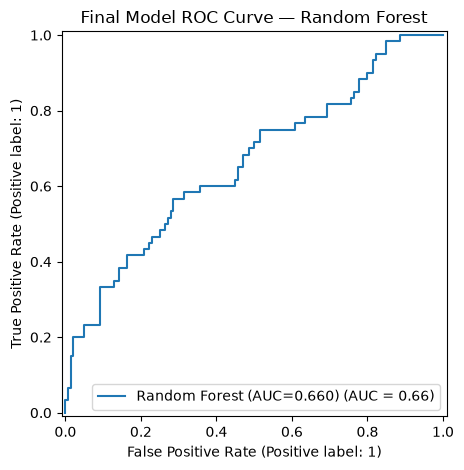

In [30]:
# 27. Final ROC curve
RocCurveDisplay.from_predictions(
    y_test, final_prob,
    name=f"{final_model_name} (AUC={roc_auc_score(y_test, final_prob):.3f})"
)
plt.title(f"Final Model ROC Curve — {final_model_name}")
plt.tight_layout()
plt.show()


## 10. Feature importance / model coefficients

For tree-based final models, feature importance shows which encoded features contribute most to the model's decisions.
For Logistic Regression, the absolute coefficient magnitude is used to rank features; the sign indicates the direction of association with the `bad` class.


,Feature,Importance
2,num__Credit amount,0.215317
3,num__Duration,0.175026
0,num__Age,0.161341
1,num__Job,0.057418
21,cat__Purpose_radio/TV,0.031037
14,cat__Checking account_moderate,0.028890
7,cat__Housing_own,0.028092
13,cat__Checking account_little,0.027267
9,cat__Saving accounts_little,0.026465
17,cat__Purpose_car,0.024902


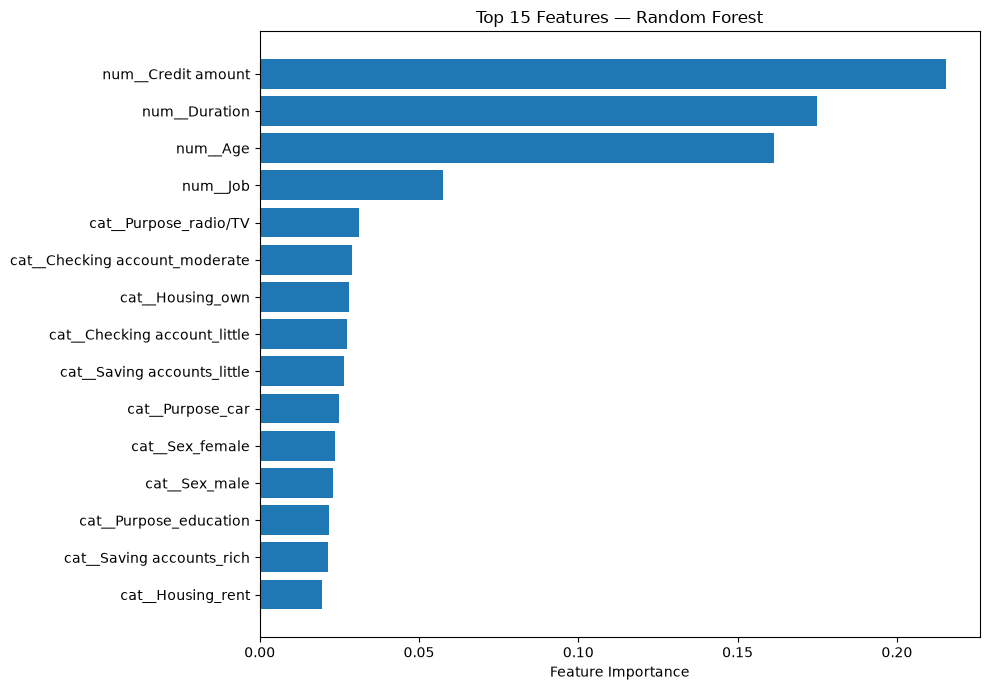

In [31]:
# 28. Feature importance or Logistic Regression coefficients
model_step = final_model.named_steps["model"]
preprocessor_fitted = final_model.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()

if hasattr(model_step, "feature_importances_"):
    values = model_step.feature_importances_
    importance_type = "Feature Importance"
else:
    # Logistic Regression: use absolute coefficients for ranking.
    values = np.abs(model_step.coef_[0])
    importance_type = "Absolute Coefficient"

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": values
}).sort_values("Importance", ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(10,7))
top_features = feature_importance.head(15).sort_values("Importance")
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title(f"Top 15 Features — {final_model_name}")
plt.xlabel(importance_type)
plt.tight_layout()
plt.show()


## 11. Business interpretation

### Credit-risk perspective

The model is designed to help a lender identify applicants who may have a higher probability of bad credit risk.

A practical deployment should not rely on a single accuracy number. The cost of incorrectly approving a risky borrower can be substantially different from the cost of incorrectly rejecting a safe borrower.

Therefore, the probability threshold can eventually be adjusted according to the bank's risk appetite.

### Key preprocessing decision

Instead of deleting incomplete customers, we retained the original observations and imputed missing categorical values. This gives the model access to substantially more training information while keeping preprocessing reproducible and leakage-safe.


In [32]:
# 29. Dataset-retention summary
summary = pd.DataFrame({
    "Stage": [
        "Original dataset",
        "After dropna (old approach)",
        "Corrected imputation approach"
    ],
    "Rows": [
        len(df),
        len(df.dropna()),
        len(df)
    ]
})

summary["Rows retained (%)"] = (summary["Rows"] / len(df) * 100).round(2)
display(summary)


,Stage,Rows,Rows retained (%)
0,Original dataset,1000,100.0
1,After dropna (old approach),522,52.2
2,Corrected imputation approach,1000,100.0


In [33]:
# 30. Export final results
final_results = tuned_results_df.drop(columns=["Best Parameters"]).copy()
final_results.to_csv("imputation_model_results_end_to_end.csv", index=False)

joblib.dump(final_model, "final_credit_risk_model_end_to_end.joblib")

print("Saved:")
print("- imputation_model_results_end_to_end.csv")
print("- final_credit_risk_model_end_to_end.joblib")


Saved:
- imputation_model_results_end_to_end.csv
- final_credit_risk_model_end_to_end.joblib


# 12. Final conclusion

This project developed an end-to-end German Credit Risk classification system.

### Workflow
**Data loading → EDA → Missing-value analysis → Imputation → Encoding → Stratified split → Class-imbalance handling → Model training → Hyperparameter tuning → Evaluation → Final model → Feature importance / coefficients → Business interpretation**

### Main methodological improvement
The original `dropna()` approach discarded a large proportion of observations. The corrected project uses **pipeline-based imputation**, retaining the full dataset and avoiding leakage.

### Model comparison
The project now compares **Logistic Regression, Decision Tree, Random Forest, Extra Trees and XGBoost**. Logistic Regression is included as an interpretable linear classification baseline, while the tree-based models can capture nonlinear relationships.

**End of project.**
